# Synthetic Control Method

# Data

In [1]:
import pandas as pd
from causalis.scenarios.synthetic_control.dgp import generate_scm_gamma_26

df = generate_scm_gamma_26(return_panel_data=False, include_oracles=True)

n_post_periods = 3

treated = df[df["unit_id"] == "treated"].copy()
post_treated = treated.tail(n_post_periods)

print(f' Ground-truth ATTE is {post_treated["tau_realized_true"].mean()}')

 Ground-truth ATTE is 2.411428552252994


In [2]:
df.head()

,unit_id,is_treated_unit,calendar_time,observed,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true,treatment_start
0,donor_1,0,2000-01,1,18.189341,18.189341,0.0,15.423696,15.423696,0.0,2002-02
1,donor_1,0,2000-02,1,10.538797,10.538797,0.0,17.675115,17.675115,0.0,2002-02
2,donor_1,0,2000-03,1,17.229170,17.229170,0.0,16.418726,16.418726,0.0,2002-02
3,donor_1,0,2000-04,1,17.165807,17.165807,0.0,14.770918,14.770918,0.0,2002-02
4,donor_1,0,2000-05,1,13.126480,13.126480,0.0,12.520843,12.520843,0.0,2002-02


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_unit="treated",
    treatment_start= pd.Period('2002-02', 'M'),
)
paneldata

PanelDataSCM(df=(308, 3), unit_col='unit_id', time_col='calendar_time', time_freq='M', y='y', treated_unit='treated', treatment_start=Period('2002-02', 'M'), donor_units=['donor_1', 'donor_10', 'donor_2', 'donor_3', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [4]:
paneldata.df.head()

,unit_id,calendar_time,y
0,donor_1,2000-01,18.189341
1,donor_1,2000-02,10.538797
2,donor_1,2000-03,17.229170
3,donor_1,2000-04,17.165807
4,donor_1,2000-05,13.126480


# EDA

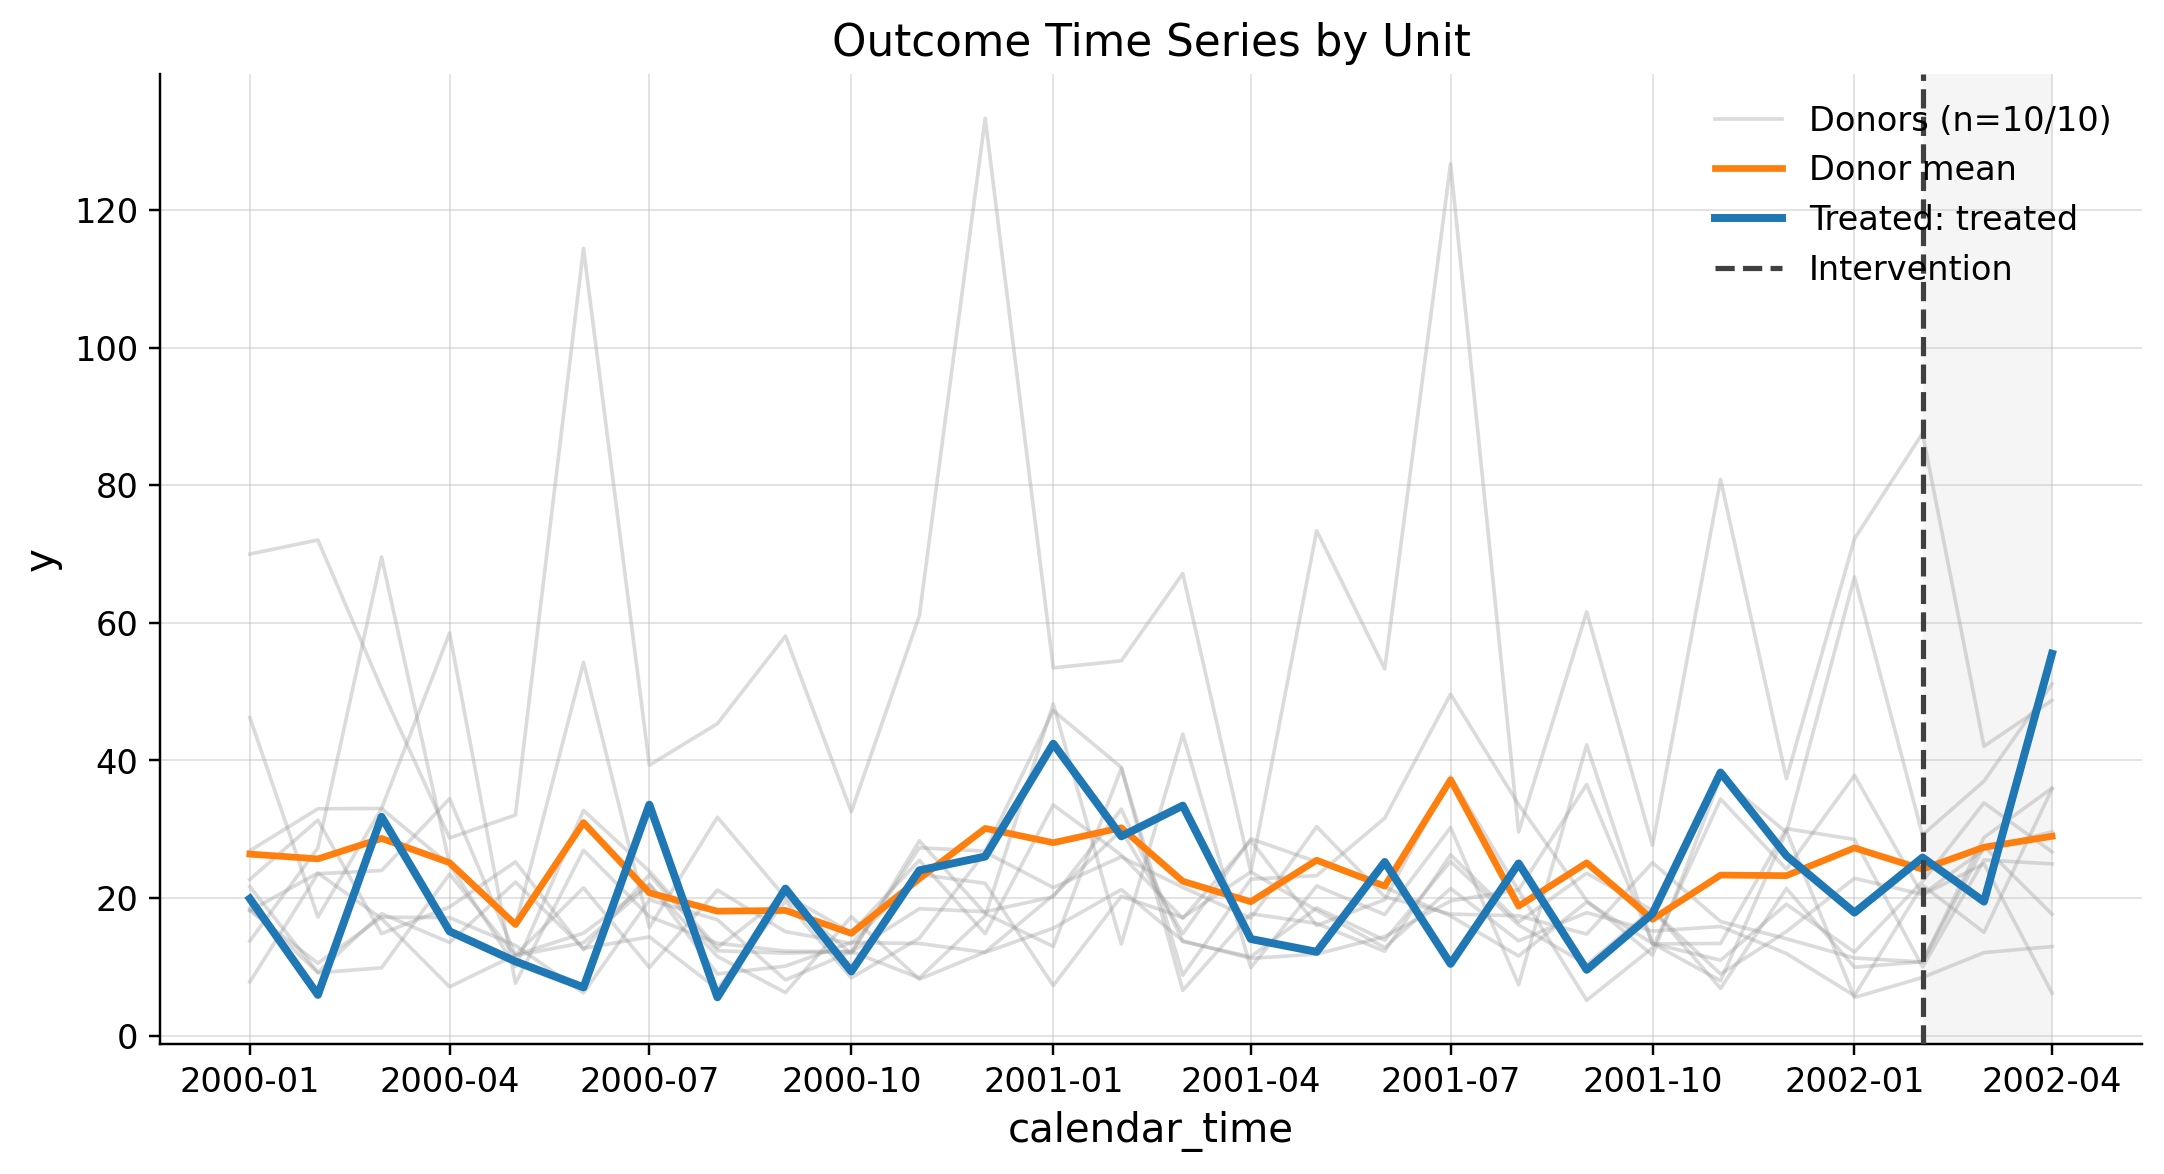

In [5]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)

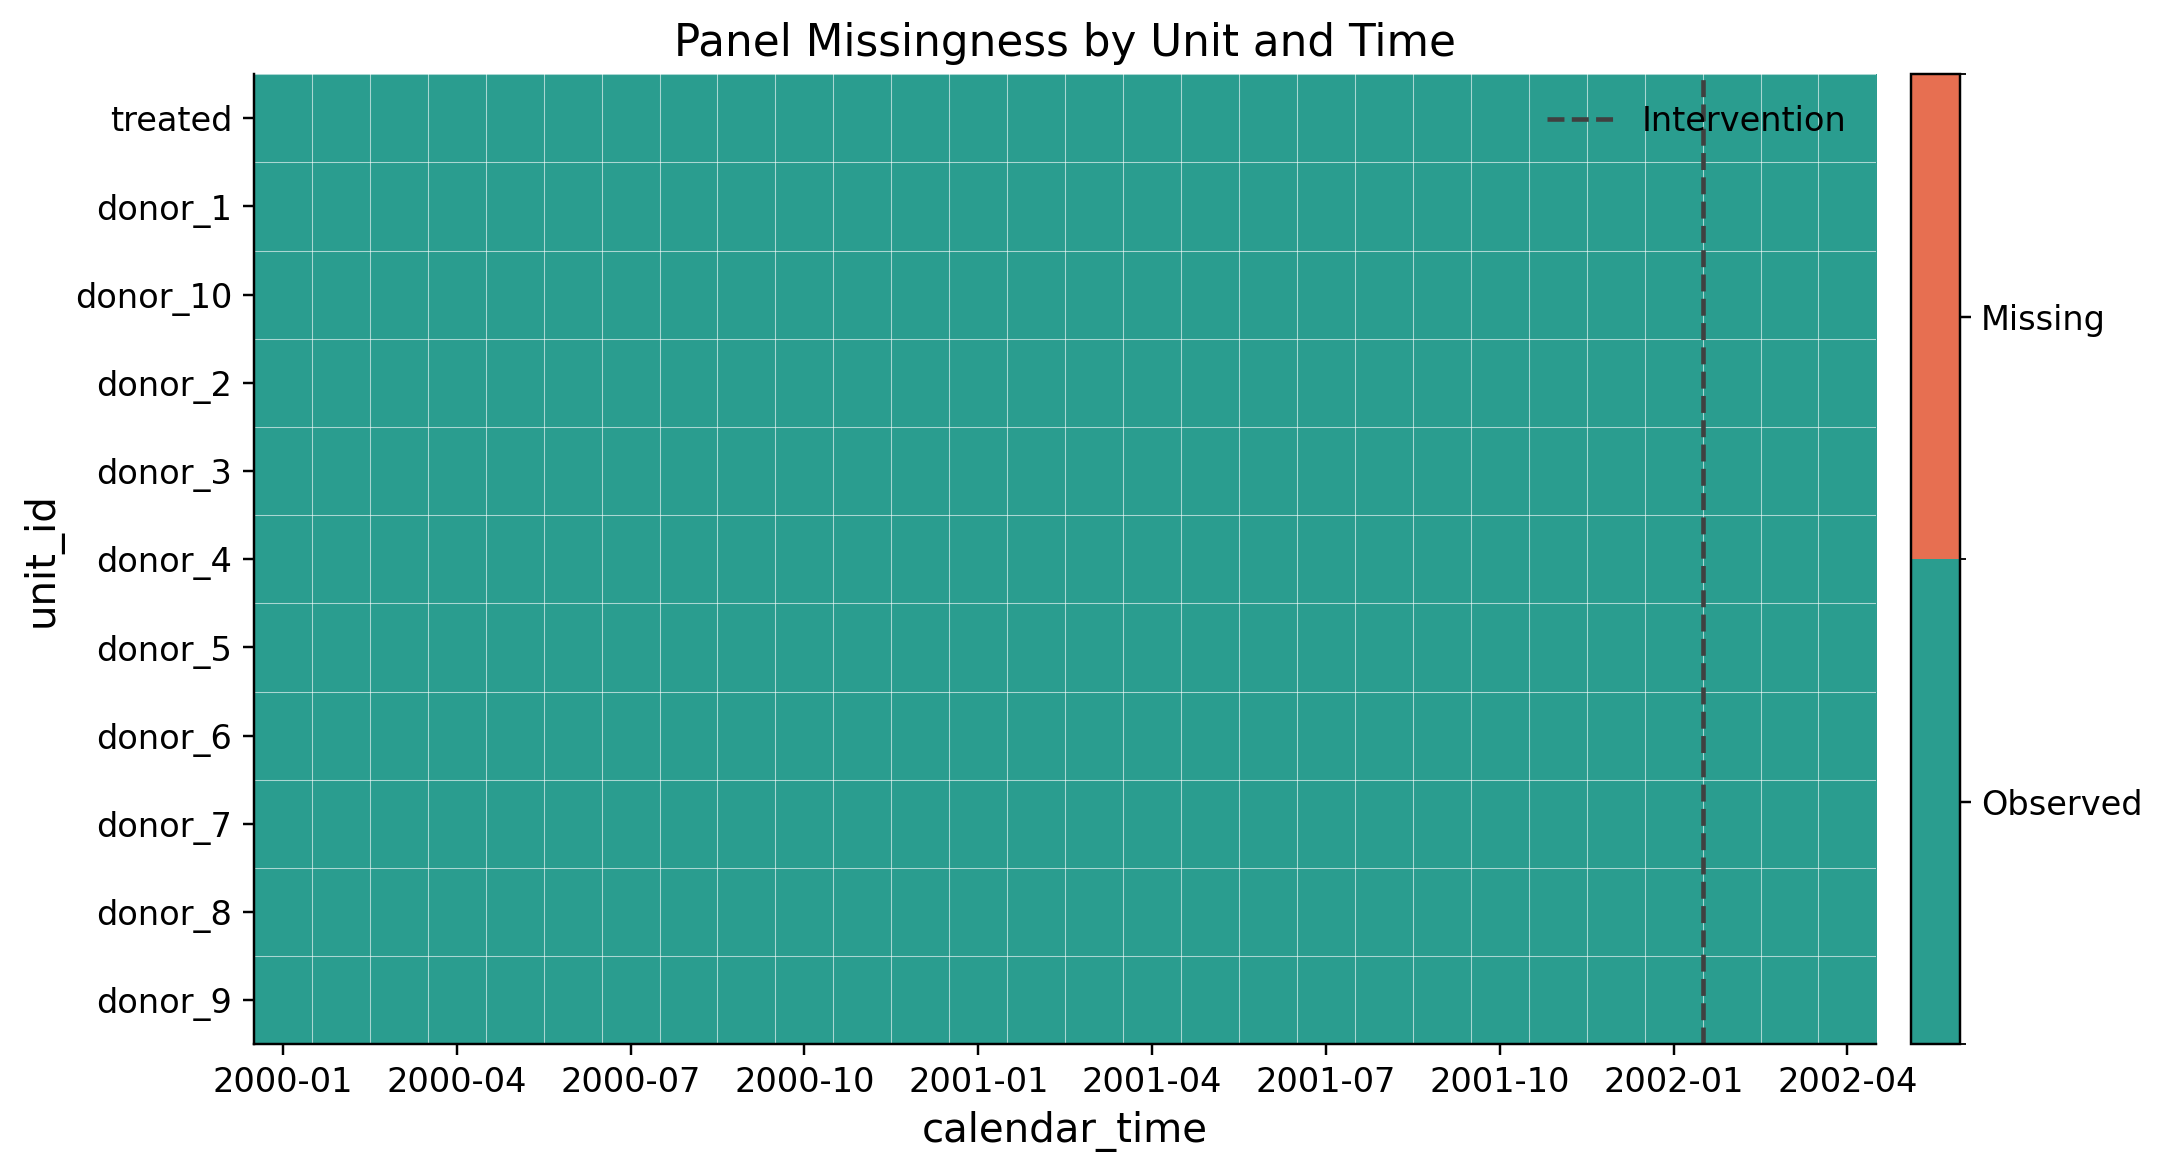

In [6]:
from causalis.scenarios.synthetic_control.refutation import missing_panel_plot

missing_panel_plot(paneldata)

# Inference

In [7]:
from causalis.scenarios.synthetic_control import SyntheticControl
model = SyntheticControl().fit(paneldata)
result = model.estimate()

In [8]:
result.summary()

,value
field,
estimand,ATTE
model,AugmentedSyntheticControl
value,16.3467
value_relative,94.5648
alpha,0.0500
p_value,0.3636
is_significant,False


# Refutation

{'metrics': {'n_donors': 10,
  'n_pre': 25,
  'n_post': 3,
  'pre_rmse_sc': 8.649225343534235,
  'pre_rmse_aug': 7.503061336042041,
  'att_sc': 15.15316375510721,
  'att_aug': 16.346694031370156,
  'max_weight_sc': 0.5543331597073966,
  'max_abs_weight_aug': 0.70646370866135,
  'l1_norm_weight_aug': 2.2288207542947633,
  'cond_augmented_gram': 544.2553348869866,
  'n_placebos': 10,
  'min_possible_p': 0.09090909090909091,
  'p_value_att': 0.36363636363636365,
  'ci_low_abs': None,
  'ci_high_abs': None,
  'placebo_ci_is_unbounded': True,
  'missing_cell_fraction': None,
  'completion_converged': None,
  'completion_effective_rank': None,
  'mean_gap_last_k_pre_sc': 6.631886971031491,
  'mean_gap_last_k_pre_aug': 3.414801628565377,
  'pre_tail_k_used': 3}}

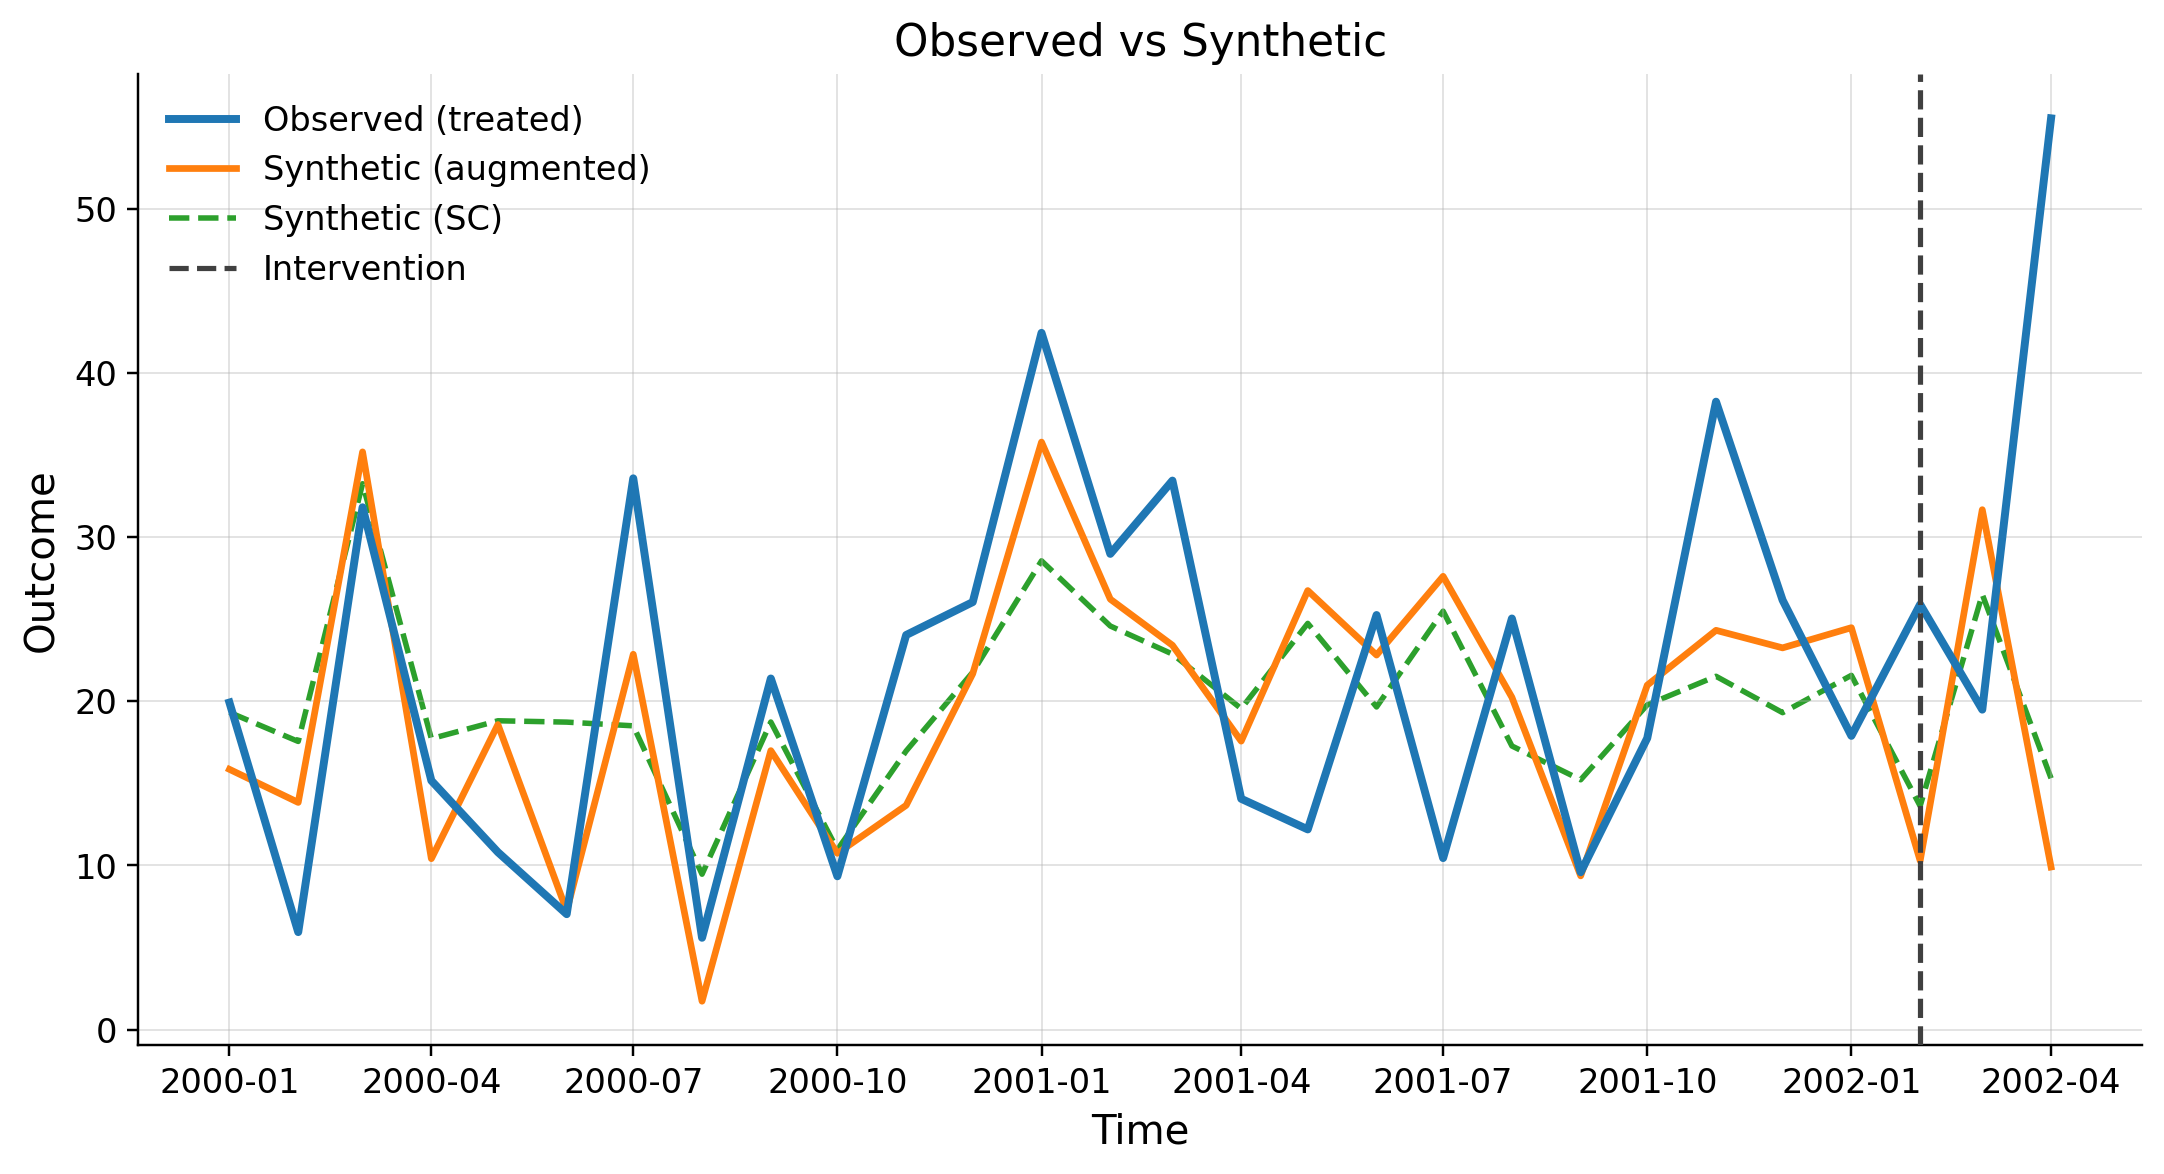

In [10]:
from causalis.scenarios.synthetic_control.refutation import observed_vs_synthetic_plot
observed_vs_synthetic_plot(result)

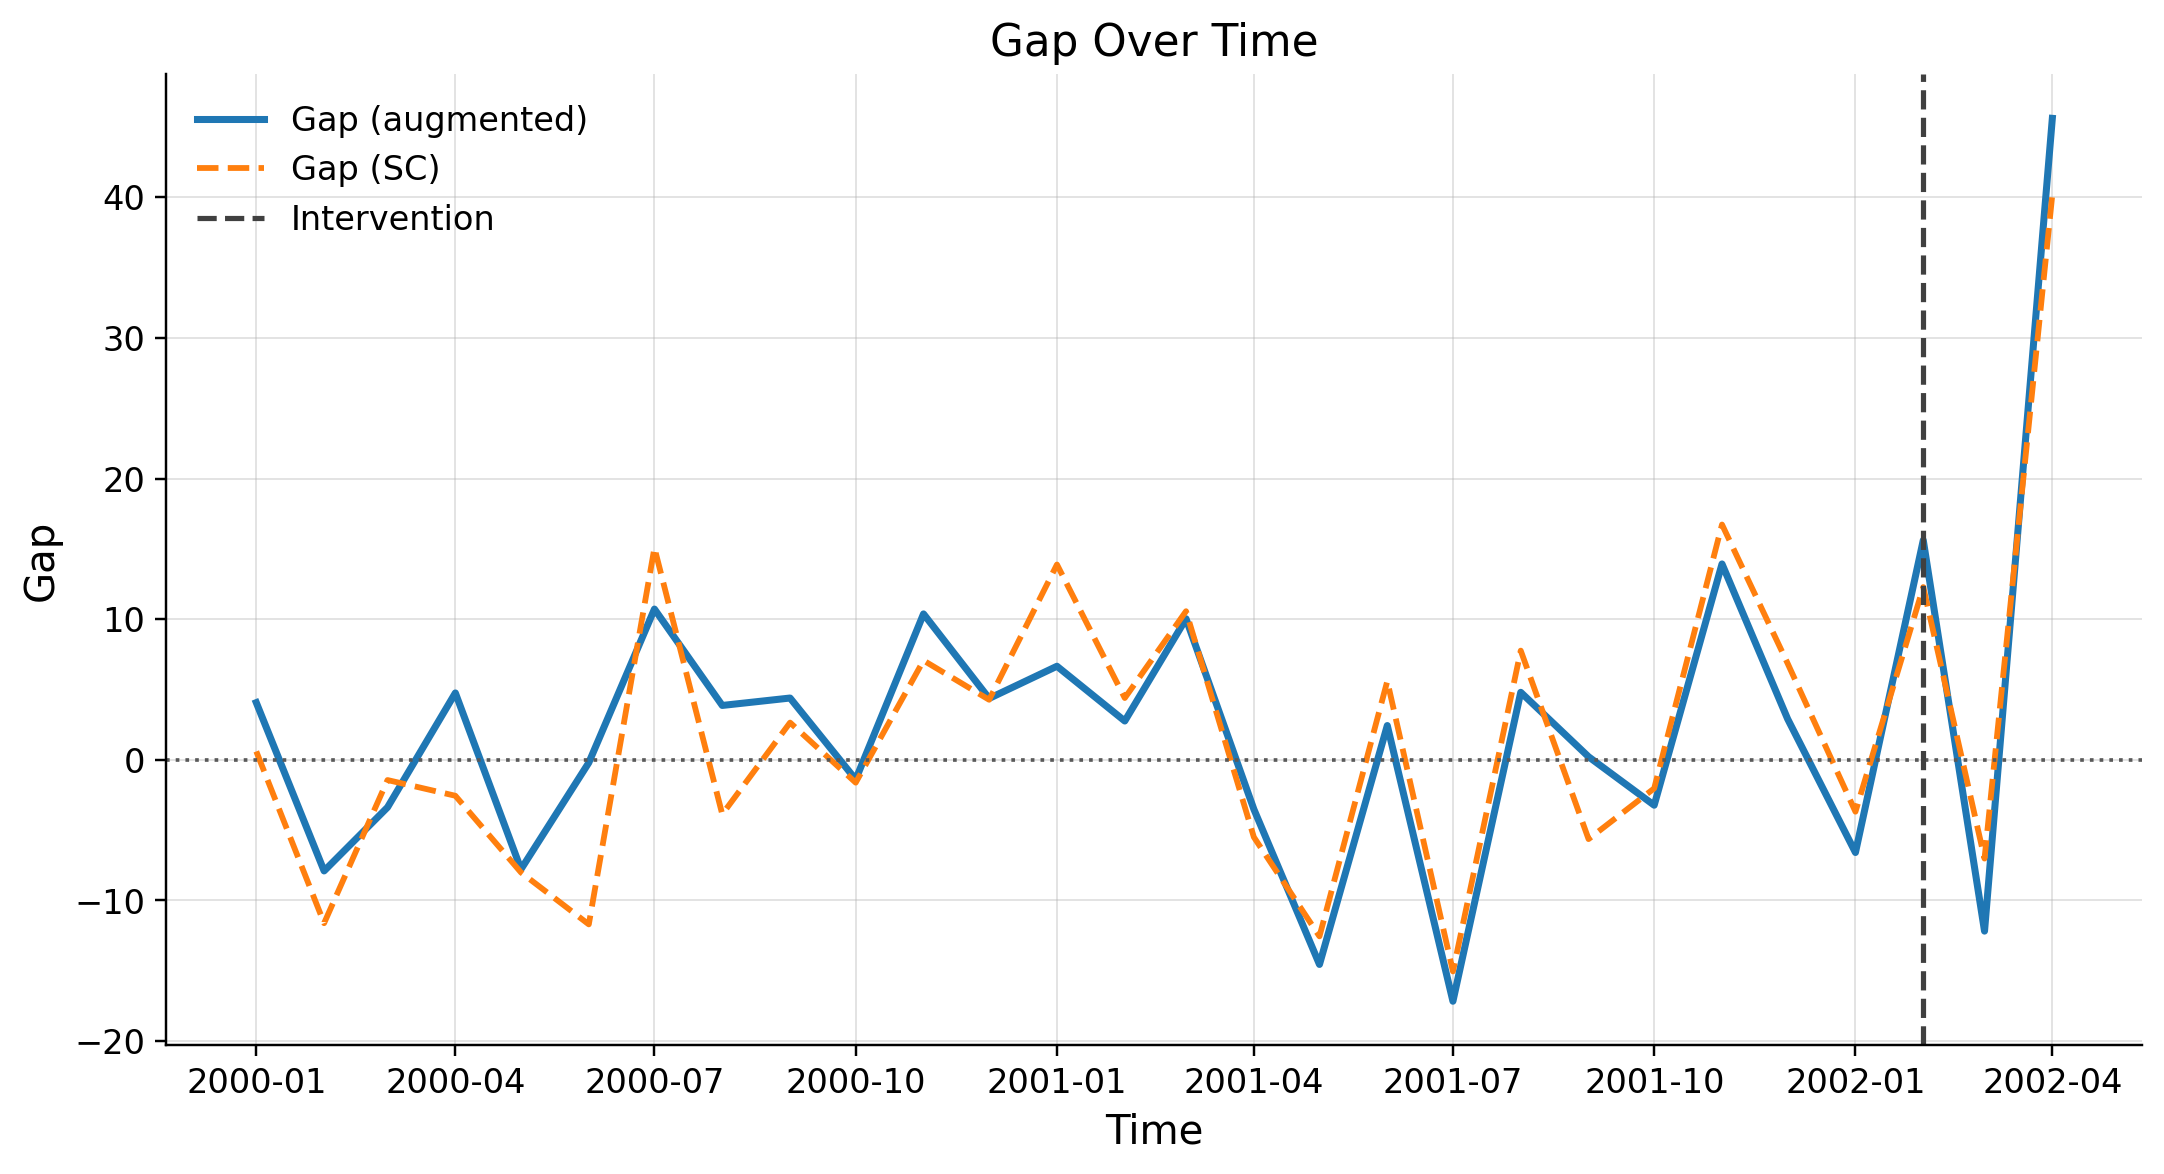

In [11]:
from causalis.scenarios.synthetic_control.refutation import gap_over_time_plot
gap_over_time_plot(result)


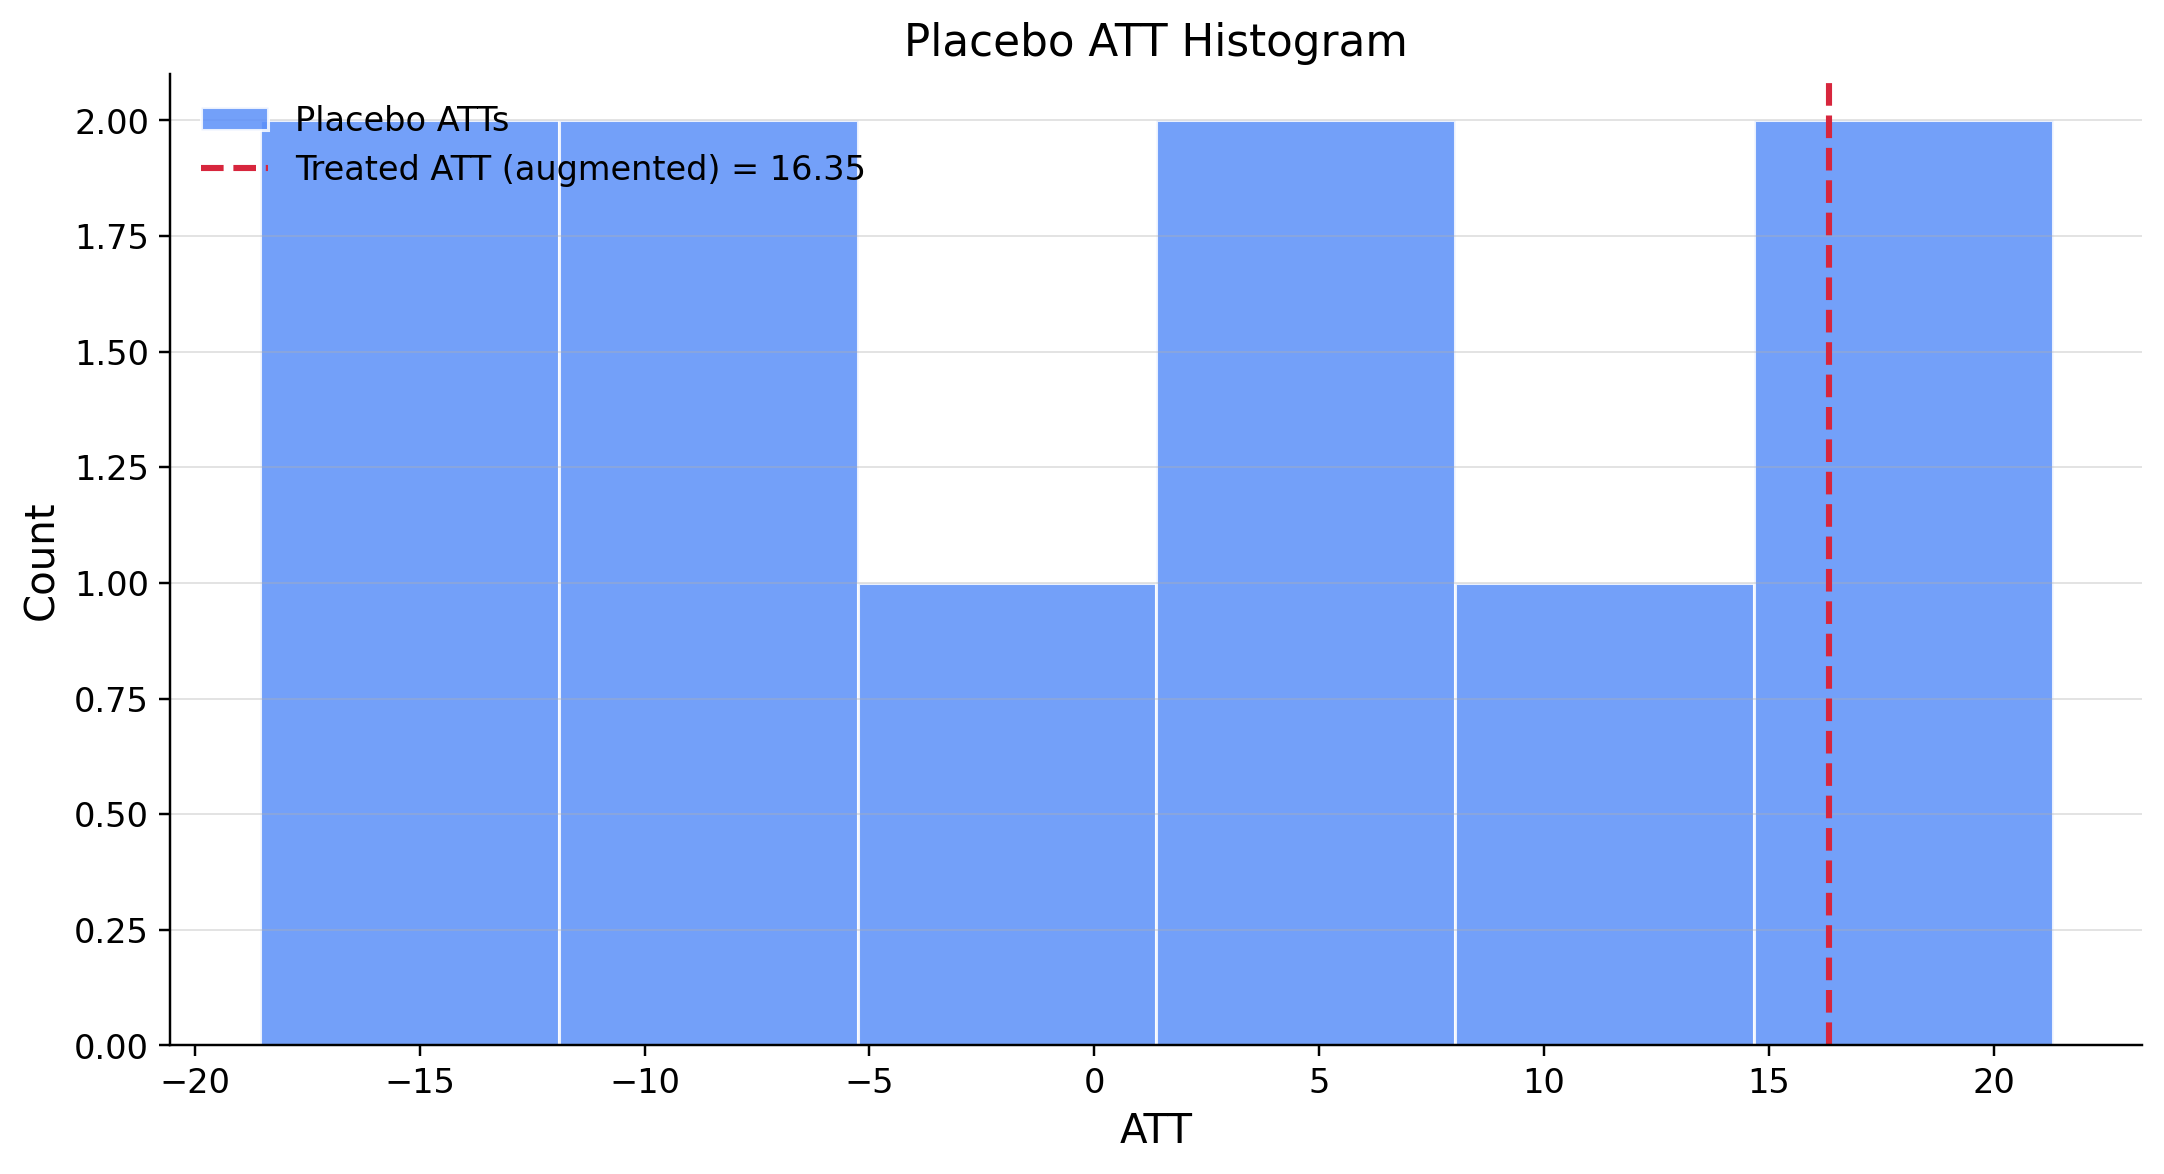

In [12]:
from causalis.scenarios.synthetic_control.refutation import placebo_att_histogram_plot
placebo_att_histogram_plot(result)